In [1]:
!unzip '/content/archive (1).zip'

unzip:  cannot find or open /content/archive (1).zip, /content/archive (1).zip.zip or /content/archive (1).zip.ZIP.


In [1]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Conv2D, BatchNormalization, Reshape, Conv2DTranspose, Dropout, MaxPooling2D, LayerNormalization, Rescaling, Normalization
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.initializers import RandomNormal
from IPython.display import Image, display
import PIL
from PIL import ImageOps
from tensorflow.data.experimental import AUTOTUNE
from tensorflow.keras.models import Model,Sequential
import scipy.io

2026-06-24 03:51:26.893930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782273087.081322      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782273087.132969      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782273087.563754      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782273087.563799      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782273087.563802      58 computation_placer.cc:177] computation placer alr

In [5]:

from scipy.ndimage import gaussian_filter
from scipy.spatial import KDTree
from typing import Optional


In [6]:
IN_X, IN_Y = 768, 1024
OUT_X, OUT_Y = 96, 128
SUBSAMPLING_FACTOR = 8

In [7]:
def generate_density_map_adaptive1(
    image_shape,
    points,
    k=3,
    beta=0.3,
    min_sigma=1.0,
    max_sigma=None,
    point_format="xy",      # "xy" hoặc "yx"
    flip_y=False            # True nếu cần lật trục Y
):

    height, width = image_shape
    density_map = np.zeros((height, width), dtype=np.float32)

    N = len(points)

    if N == 0:
        return density_map

    points = np.asarray(points).copy()

    # ---------------------------
    # Chuẩn hóa tọa độ về (y,x)
    # ---------------------------
    if point_format == "xy":
        points = points[:, [1, 0]]

    # ---------------------------
    # Lật trục Y nếu cần
    # ---------------------------
    if flip_y:
        points[:, 0] = height - 1 - points[:, 0]

    # ---------------------------
    # KNN tính sigma
    # ---------------------------
    if N > 1:

        tree = KDTree(points)

        m = min(k, N - 1)

        distances, _ = tree.query(points, k=m + 1)

        avg_distances = np.mean(
            distances[:, 1:m + 1],
            axis=1
        )

        sigmas = beta * avg_distances

        sigmas = np.maximum(sigmas, min_sigma)

        if max_sigma is not None:
            sigmas = np.minimum(sigmas, max_sigma)

    else:

        sigmas = np.array([15.0])

    # ---------------------------
    # Sinh density map
    # ---------------------------
    for pt, sigma_i in zip(points, sigmas):

        y_orig, x_orig = pt

        # Clamp integer coordinates for patch bounds calculation
        y_idx = int(round(y_orig))
        x_idx = int(round(x_orig))

        y_clamped_idx = np.clip(y_idx, 0, height - 1)
        x_clamped_idx = np.clip(x_idx, 0, width - 1)

        radius = int(np.ceil(3 * sigma_i))

        y_min = max(0, y_clamped_idx - radius)
        y_max = min(height - 1, y_clamped_idx + radius)

        x_min = max(0, x_clamped_idx - radius)
        x_max = min(width - 1, x_clamped_idx + radius)

        # Skip if the patch is invalid (e.g., range is inverted or empty after clamping)
        if y_min > y_max or x_min > x_max:
            continue

        yy, xx = np.mgrid[
            y_min:y_max + 1,
            x_min:x_max + 1
        ]

        # Use original y_orig, x_orig for calculating distances from center of Gaussian
        d_sq = (yy - y_orig) ** 2 + (xx - x_orig) ** 2

        gaussian_patch = np.exp(
            -d_sq / (2 * sigma_i**2)
        )

        # Handle cases where gaussian_patch sum might be zero if it's an empty array
        if gaussian_patch.sum() > 0:
            gaussian_patch /= gaussian_patch.sum()
        else:
            continue # Skip if patch is empty or all zeros

        density_map[
            y_min:y_max + 1,
            x_min:x_max + 1
        ] += gaussian_patch

    return density_map

In [18]:
mat = scipy.io.loadmat('/kaggle/input/datasets/nguynvitmnh/processed/processed/train_data/ground-truth/GT_IMG_3_crop3.mat')
print(mat.keys())
len(mat['annPoints'])

dict_keys(['__header__', '__version__', '__globals__', 'annPoints', 'number'])


42

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9544203..1.6124358].


(96, 128)


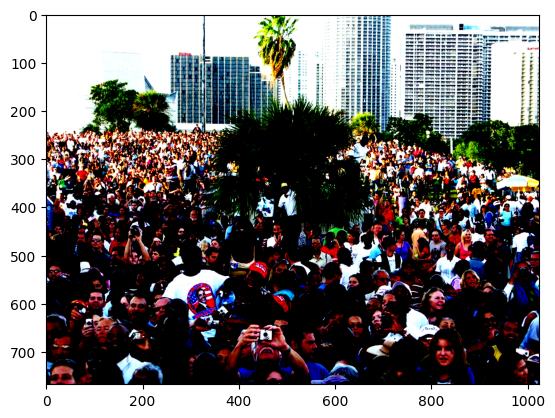

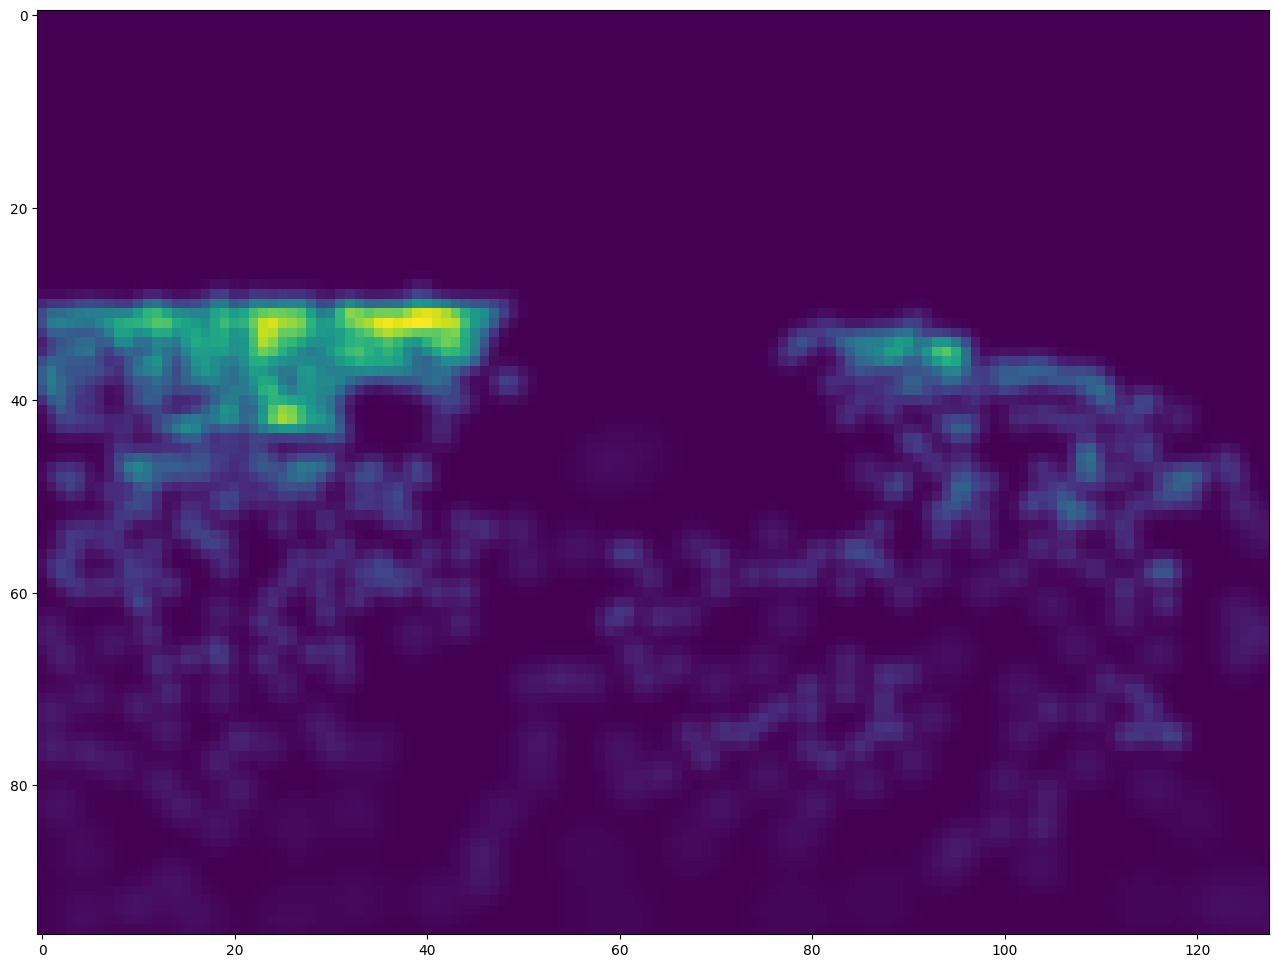

In [8]:
train_images ='/content/ShanghaiTech/part_A/train_data/images/'
train_maps = '/content/ShanghaiTech/part_A/train_data/ground-truth/'

IN = 'IMG_20'
im_array = img_to_array(load_img('/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_A/train_data/images/IMG_236.jpg', target_size=( IN_X, IN_Y)))

im_array /= 255
im_array[:,:,0] = (im_array[:,:,0] - np.mean(im_array[:,:,0]))/ np.std(im_array[:,:,0])
im_array[:,:,1] = (im_array[:,:,1] - np.mean(im_array[:,:,1]))/ np.std(im_array[:,:,1])
im_array[:,:,2] = (im_array[:,:,2] - np.mean(im_array[:,:,2]))/ np.std(im_array[:,:,2])

X = im_array
plt.imshow(X)

mat = scipy.io.loadmat('/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_A/train_data/ground-truth/GT_IMG_236.mat')
points = mat['image_info'][0][0][0][0][0]
#points = mat['annPoints']


# Convert points to a float array before division to avoid TypeError

points /= SUBSAMPLING_FACTOR
y = generate_density_map_adaptive1((OUT_X, OUT_Y), points,)
print(y.shape)

plt.figure(figsize=(20,12))
plt.imshow(y)
plt.show()

In [13]:
class DataGenerator(tf.keras.utils.Sequence):

    def __init__(self, images, maps, batch_size, SUBSAMPLING_FACTOR):

        super().__init__()

        self.images = images
        self.maps = maps
        self.batch_size = batch_size
        self.SUBSAMPLING_FACTOR = SUBSAMPLING_FACTOR

        # Sort để ảnh và ground truth cùng thứ tự
        self.image_list = sorted(os.listdir(images))
        self.map_list = sorted(os.listdir(maps))

    # Keras 3 yêu cầu property này
    @property
    def num_batches(self):
        return self.__len__()

    def __len__(self):

        # ceil để không bị mất batch cuối
        return int(np.ceil(len(self.image_list) / self.batch_size))

    def __getitem__(self, idx):

        X = []
        y = []

        batch_start = idx * self.batch_size
        batch_end = min((idx + 1) * self.batch_size,
                        len(self.image_list))

        eps = 1e-8

        for j in range(batch_start, batch_end):

            try:

                # ===== IMAGE PATH =====
                image_path = os.path.join(
                    self.images,
                    self.image_list[j]
                )

                # ===== MAP PATH =====
                map_path = os.path.join(
                    self.maps,
                    self.map_list[j]
                )

                # ===== LOAD IMAGE =====
                im_array = img_to_array(
                    load_img(
                        image_path,
                        target_size=(IN_X, IN_Y)
                    )
                )

                im_array = im_array.astype(np.float32)

                # normalize [0,1]
                im_array /= 255.0

                # standardize từng channel
                for c in range(3):

                    mean = np.mean(im_array[:, :, c])
                    std = np.std(im_array[:, :, c])

                    im_array[:, :, c] = (
                        im_array[:, :, c] - mean
                    ) / (std + eps)

                X.append(im_array)

                # ===== LOAD MAT =====
                mat = scipy.io.loadmat(map_path)

                points = mat['image_info'][0][0][0][0][0]

                points = points.astype(np.float32)

                points /= self.SUBSAMPLING_FACTOR

                # ===== DENSITY MAP =====
                density_map =  generate_density_map_adaptive1((OUT_X, OUT_Y), points,)

                density_map = density_map.astype(np.float32)

                y.append(density_map)

            except Exception as e:

                print(e)

                raise e

        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.float32)


        return X, y



In [8]:
train_images ='/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_A/train_data/images/'
train_maps = '/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_A/train_data/ground-truth/'
BATCH_SIZE = 1
EPOCH =300

In [9]:
train_gen = DataGenerator(train_images, train_maps, BATCH_SIZE, SUBSAMPLING_FACTOR = SUBSAMPLING_FACTOR)

In [10]:
def get_base_model():
  base_model = VGG16(weights='imagenet',input_shape=(IN_X,IN_Y,3), include_top=False)
  block4_conv3 = [base_model.get_layer(layer_name).output for layer_name in ["block4_conv3"]]

  return tf.keras.Model(
      inputs=[base_model.inputs], outputs = block4_conv3
  )

get_base_model().summary()


I0000 00:00:1781885752.493578      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781885752.499711      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 768, 1024, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 768, 1024, 64)  │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 768, 1024, 64)  │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 384, 512, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 384, 512, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 384, 512, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 192, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 192, 256, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 192, 256, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 192, 256, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 96, 128, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 96, 128, 512)   │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 96, 128, 512)   │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 96, 128, 512)   │     2,359,808 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,635,264 (29.13 MB)

 Trainable params: 7,635,264 (29.13 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
inputs = tf.keras.Input(shape=(IN_X,IN_Y,3))
x = get_base_model()(inputs)[0]
init = RandomNormal(stddev= 0.01)

x = Conv2D(512, (3, 3), activation='relu',dilation_rate= 2 , padding='same', kernel_initializer=init)(x)
x = Conv2D(512, (3, 3), activation='relu',dilation_rate= 2 , padding='same', kernel_initializer=init)(x)
x = Conv2D(512, (3, 3), activation='relu',dilation_rate= 2 , padding='same', kernel_initializer=init)(x)
x = Conv2D(256, (3, 3), activation='relu',dilation_rate= 2 , padding='same', kernel_initializer=init)(x)
x = Conv2D(128, (3, 3), activation='relu',dilation_rate= 2 , padding='same', kernel_initializer=init)(x)
x = Conv2D(64, (3, 3), activation='relu',dilation_rate= 2 , padding='same', kernel_initializer=init)(x)
x = Conv2D(1, (1, 1), activation='relu',dilation_rate= 2 , padding='same', kernel_initializer=init)(x)

out = Reshape((OUT_X, OUT_Y))(x)
model = tf.keras.Model(inputs=inputs, outputs=out)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 768, 1024, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 96, 128, 512)   │     7,635,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 128, 512)   │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 128, 512)   │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 128, 512)   │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 128, 256)   │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 96, 128, 128)   │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 96, 128, 64)    │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 96, 128, 1)     │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 96, 128)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,263,489 (62.04 MB)

 Trainable params: 16,263,489 (62.04 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:

def custom_loss(y_true, y_pred):

  return tf.sqrt(tf.math.reduce_sum(tf.square(y_true - y_pred)))

In [13]:
LR = 1e-5
model.compile(
    loss = 'mse',
    optimizer = Adam(learning_rate = LR,),
    metrics = ['accuracy'],

)
checkpoint_filepath = '/kaggle/working/checkpoints/checkpoint/people_counting/CSRNet.hdf5'

In [14]:
callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='/kaggle/working/best_model.keras',
    monitor='loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False
)

In [15]:

history = model.fit(
    train_gen,
    verbose = 1,
    shuffle = True,
    epochs=EPOCH,
    callbacks=[callback]
)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_20']]
Received: inputs=['Tensor(shape=(None, 768, 1024, 3))']
  warnings.warn(msg)
I0000 00:00:1781885759.630006     140 service.cc:152] XLA service 0x7a3ff400ac90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781885759.630070     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781885759.630077     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781885760.622712     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-19 16:16:02.997525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 16:16:03.

300/300 ━━━━━━━━━━━━━━━━━━━━ 150s 390ms/step - accuracy: 0.0103 - loss: 0.0135
Epoch 2/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 120s 398ms/step - accuracy: 0.0114 - loss: 0.0133
Epoch 3/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 120s 400ms/step - accuracy: 0.0134 - loss: 0.0118
Epoch 4/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 120s 398ms/step - accuracy: 0.0123 - loss: 0.0113
Epoch 5/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 119s 396ms/step - accuracy: 0.0126 - loss: 0.0116
Epoch 6/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 119s 397ms/step - accuracy: 0.0127 - loss: 0.0101
Epoch 7/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 119s 395ms/step - accuracy: 0.0128 - loss: 0.0103
Epoch 8/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 119s 397ms/step - accuracy: 0.0122 - loss: 0.0101
Epoch 9/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 119s 398ms/step - accuracy: 0.0128 - loss: 0.0097
Epoch 10/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 118s 393ms/step - accuracy: 0.0113 - loss: 0.0108
Epoch 11/300
300/300 ━━━━━━━━━━━━━━━━━━━━ 119s 395ms/step - accuracy: 0.0128 - loss: 0.0094
Epoch 12/

In [9]:
from tensorflow.keras.models import load_model
IN = "IMG_1"

model = load_model('/kaggle/input/datasets/nguynvitmnh/modelcuame/best_model206.keras')

I0000 00:00:1782273158.353181      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782273158.359181      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9544203..1.6124358].
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=['Tensor(shape=(1, 768, 1024, 3))']
  warnings.warn(msg)
I0000 00:00:1782273171.429861     138 service.cc:152] XLA service 0x7c321800b270 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782273171.429919     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782273171.429926     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782273171.642396     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-24 03:52:53.674484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out:

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


I0000 00:00:1782273181.080465     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Số người thật là:  741
Số người dự đoán là:  697.18945


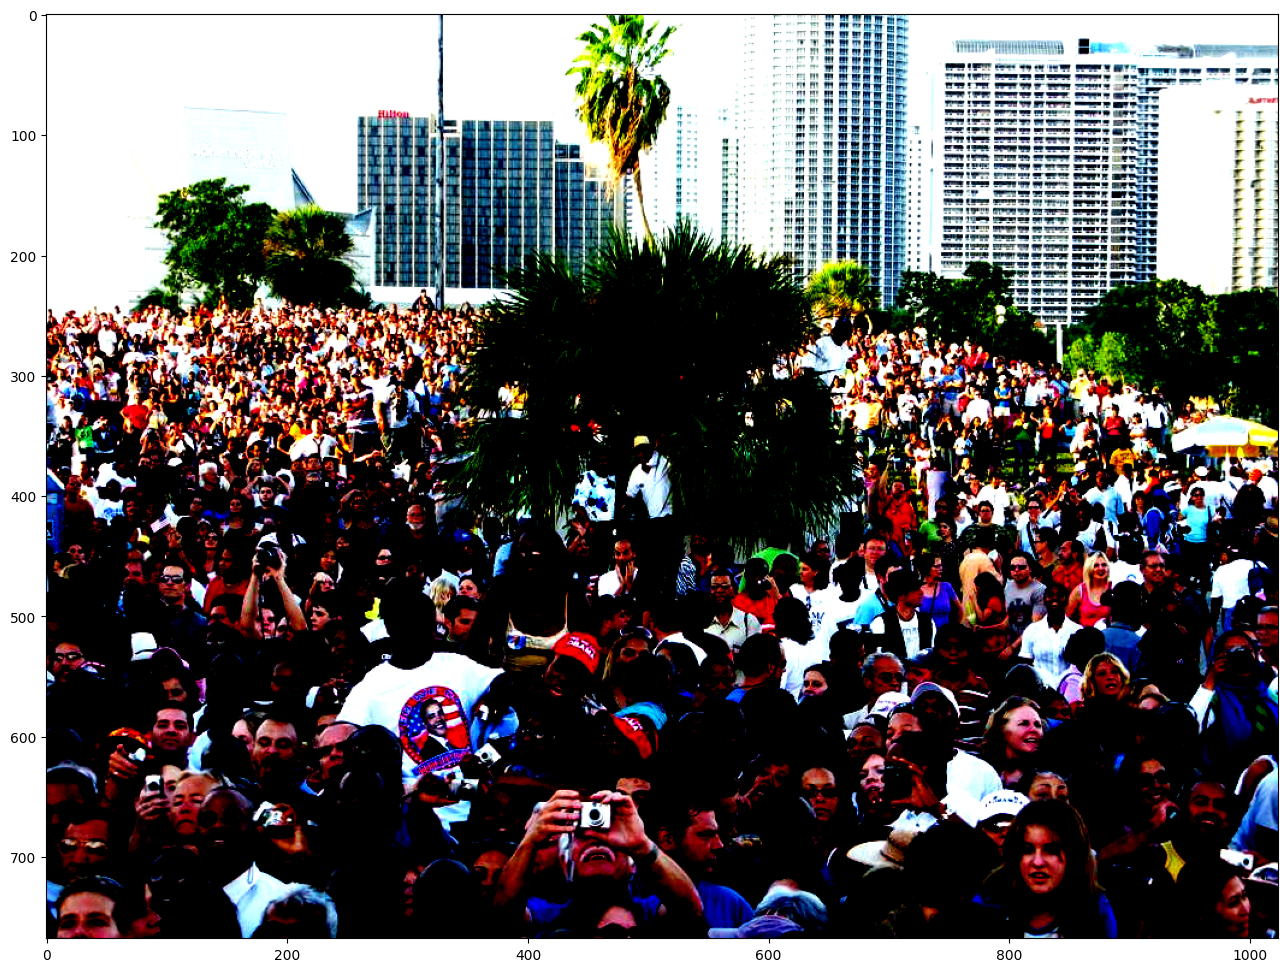

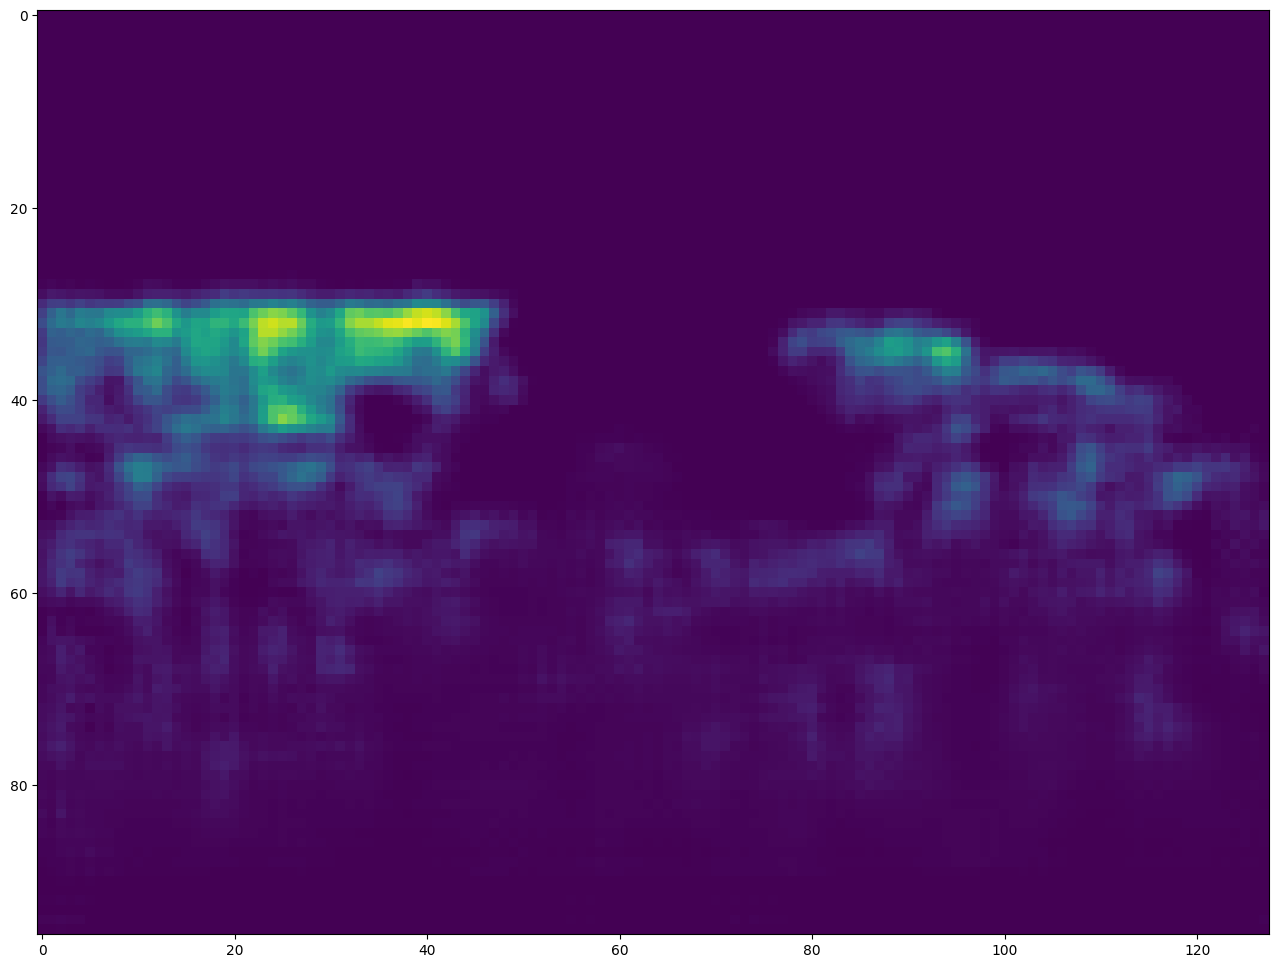

In [10]:

#test_images ='/content/ShanghaiTech/part_A/test_data/images/'
#test_maps = '/content/ShanghaiTech/part_A/test_data/ground-truth/'

im_array = img_to_array(load_img("/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_A/train_data/images/IMG_236.jpg", target_size=( IN_X, IN_Y)))

im_array /= 255
im_array[:,:,0] = (im_array[:,:,0] - np.mean(im_array[:,:,0]))/ np.std(im_array[:,:,0])
im_array[:,:,1] = (im_array[:,:,1] - np.mean(im_array[:,:,1]))/ np.std(im_array[:,:,1])
im_array[:,:,2] = (im_array[:,:,2] - np.mean(im_array[:,:,2]))/ np.std(im_array[:,:,2])

plt.figure(figsize=(20,12))
plt.imshow(im_array)

output = model.predict(tf.expand_dims(im_array, axis= 0))
output = np.reshape(output,(OUT_X, OUT_Y))

n_people = np.sum(output)
mat = scipy.io.loadmat('/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_A/train_data/ground-truth/GT_IMG_236.mat')
points = mat['image_info'][0][0][0][0][0]
points /= SUBSAMPLING_FACTOR

num_gt = np.squeeze(points).shape[0]
print('Số người thật là: ', num_gt )
print('Số người dự đoán là: ', n_people)
plt.figure(figsize=(20,12))
plt.imshow(output)


plt.show()

In [11]:
import os
import scipy.io
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ==========================
# Đường dẫn tập test
# ==========================

test_images = "/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_B/test_data/images"
test_gt = "/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_B/test_data/ground-truth"

# ==========================
# Danh sách lưu kết quả
# ==========================

results = []

image_files = sorted([
    f for f in os.listdir(test_images)
    if f.endswith(".jpg")
])

for img_name in image_files:

    try:

        # ======================
        # Load ảnh
        # ======================

        img_path = os.path.join(test_images, img_name)

        im_array = img_to_array(
            load_img(
                img_path,
                target_size=(IN_X, IN_Y)
            )
        ).astype(np.float32)

        im_array /= 255.0

        # Chuẩn hóa giống lúc train
        for c in range(3):

            mean = np.mean(im_array[:, :, c])
            std = np.std(im_array[:, :, c])

            im_array[:, :, c] = (
                im_array[:, :, c] - mean
            ) / (std + 1e-8)

        # ======================
        # Predict
        # ======================

        pred_map = model.predict(
            np.expand_dims(im_array, axis=0),
            verbose=0
        )

        pred_map = pred_map.squeeze()

        pred_count = float(np.sum(pred_map))

        # ======================
        # Ground truth
        # ======================

        gt_name = img_name.replace(
            "IMG_",
            "GT_IMG_"
        ).replace(
            ".jpg",
            ".mat"
        )

        gt_path = os.path.join(
            test_gt,
            gt_name
        )

        mat = scipy.io.loadmat(gt_path)

        points = mat['image_info'][0][0][0][0][0]

        gt_count = len(points)

        # ======================
        # Lưu kết quả
        # ======================

        results.append({
            "image_path": img_path,
            "predicted_count": pred_count,
            "ground_truth_count": gt_count
        })

        print(
            f"{img_name}: "
            f"GT={gt_count}, "
            f"Pred={pred_count:.2f}"
        )

    except Exception as e:

        print(f"Lỗi ở {img_name}: {e}")

# ==========================
# Tạo DataFrame
# ==========================

df = pd.DataFrame(results)

# Sai số từng ảnh

df["abs_error"] = np.abs(
    df["predicted_count"] -
    df["ground_truth_count"]
)

# ==========================
# MAE toàn tập test
# ==========================

mae = df["abs_error"].mean()

print(f"\nMAE = {mae:.4f}")

# ==========================
# Lưu CSV
# ==========================

csv_path = "/kaggle/working/test_predictions1.csv"

df.to_csv(
    csv_path,
    index=False
)

print(f"\nĐã lưu: {csv_path}")

df.head()

IMG_1.jpg: GT=23, Pred=10.96
IMG_10.jpg: GT=181, Pred=123.48
IMG_100.jpg: GT=157, Pred=111.35
IMG_101.jpg: GT=37, Pred=19.09
IMG_102.jpg: GT=70, Pred=56.59
IMG_103.jpg: GT=57, Pred=49.52
IMG_104.jpg: GT=44, Pred=31.06
IMG_105.jpg: GT=227, Pred=160.24
IMG_106.jpg: GT=165, Pred=141.41
IMG_107.jpg: GT=476, Pred=418.82
IMG_108.jpg: GT=139, Pred=95.99
IMG_109.jpg: GT=316, Pred=187.58
IMG_11.jpg: GT=164, Pred=135.20
IMG_110.jpg: GT=110, Pred=82.23
IMG_111.jpg: GT=20, Pred=9.27
IMG_112.jpg: GT=131, Pred=134.04
IMG_113.jpg: GT=48, Pred=40.60
IMG_114.jpg: GT=183, Pred=160.14
IMG_115.jpg: GT=101, Pred=78.56
IMG_116.jpg: GT=204, Pred=185.25
IMG_117.jpg: GT=40, Pred=23.25
IMG_118.jpg: GT=143, Pred=114.79
IMG_119.jpg: GT=146, Pred=47.87
IMG_12.jpg: GT=513, Pred=351.39
IMG_120.jpg: GT=70, Pred=47.11
IMG_121.jpg: GT=175, Pred=102.67
IMG_122.jpg: GT=51, Pred=38.07
IMG_123.jpg: GT=55, Pred=66.09
IMG_124.jpg: GT=67, Pred=86.98
IMG_125.jpg: GT=72, Pred=49.06
IMG_126.jpg: GT=56, Pred=27.15
IMG_127.jpg: GT

,image_path,predicted_count,ground_truth_count,abs_error
0,/kaggle/input/datasets/nguynvitmnh/datacuame/S...,10.958766,23,12.041234
1,/kaggle/input/datasets/nguynvitmnh/datacuame/S...,123.475456,181,57.524544
2,/kaggle/input/datasets/nguynvitmnh/datacuame/S...,111.353302,157,45.646698
3,/kaggle/input/datasets/nguynvitmnh/datacuame/S...,19.093325,37,17.906675
4,/kaggle/input/datasets/nguynvitmnh/datacuame/S...,56.589558,70,13.410442


In [17]:
test_images ='/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_B/test_data/images/'
test_maps = '/kaggle/input/datasets/nguynvitmnh/datacuame/ShanghaiTech/part_B/test_data/ground-truth/'
test_gen = DataGenerator(test_images, test_maps,1, SUBSAMPLING_FACTOR = SUBSAMPLING_FACTOR)

In [18]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

ssim_scores = []

for x_batch, y_batch in test_gen:

    pred_batch = model.predict(x_batch, verbose=0)

    for gt_map, pred_map in zip(y_batch, pred_batch):

        gt_map = gt_map.squeeze()
        pred_map = pred_map.squeeze()

        score = ssim(
            gt_map,
            pred_map,
            data_range=max(
                gt_map.max(),
                pred_map.max()
            ) - min(
                gt_map.min(),
                pred_map.min()
            )
        )

        ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)

print("Mean SSIM =", mean_ssim)

Mean SSIM = 0.7516196407923272
